In [1]:
import pathlib
import pandas
import matplotlib.pyplot as plt
import seaborn

In [2]:
dir_path = pathlib.Path.home()/'OneDrive'/'gamma_control_data'
assert dir_path.exists()

#for test
for path in dir_path.glob('*/42_active_[1-3].txt'):
    print(str(path.parent).split('/')[-1], path.stem.split('_')[-1])

In [3]:
df_list = list()
for path in dir_path.glob('*/42_active_[1-3].txt'):
    df = pandas.read_csv(
        path, delimiter='\t', skiprows=6, usecols=list(range(2, 11)),
        names = [
            #'participant_name',
            #'participant_ID',
            'session_type',
            'event_name',
            '???',
            'response',
            'key',
            'mouse_X',
            'mouse_Y',
            'error_code',
            'reaction_time',
        ],
    )
    #set session types
    df.loc[df.session_type<=5, 'session_type_name'] = 'standard'
    df.loc[df.session_type>5, 'session_type_name'] = 'deviant'

    #set Hit or FalseAlarm
    df.loc[(df.session_type<=5) & (df.response=='Left'),'outcome'] = 'Correct Reject'
    df.loc[(df.session_type<=5) & (df.response=='Right'),'outcome'] = 'False Alarm'
    df.loc[(df.session_type>5) & (df.response=='Left'),'outcome'] = 'Miss'
    df.loc[(df.session_type>5) & (df.response=='Right'),'outcome'] = 'Hit'

    #exclude no response trials?
    df = df[df.response.notna()]

    pid_date = str(path.parent).split('/')[-1]
    block = int(path.stem.split('_')[-1])
    df['experiment_id'] = pid_date.split('_')[0]
    df['experiment_date'] = pid_date.split('_')[1]
    df['id_date'] = pid_date
    df['block'] = block

    df_list.append(df)

answers_df = pandas.concat(df_list)
answers_df.to_csv(dir_path/'answers.csv')
answers_df.head()

,session_type,event_name,???,response,key,mouse_X,mouse_Y,error_code,reaction_time,session_type_name,outcome,experiment_id,experiment_date,id_date,block
5,9,response,NaN,Left,Pressed,348.0,-53.0,C,9771,deviant,Miss,4699,1019,4699_1019,1
11,7,response,NaN,Left,Pressed,348.0,-53.0,C,9196,deviant,Miss,4699,1019,4699_1019,1
17,5,response,NaN,Left,Pressed,348.0,-53.0,C,9783,standard,Correct Reject,4699,1019,4699_1019,1
23,2,response,NaN,Right,Pressed,348.0,-53.0,C,8532,standard,False Alarm,4699,1019,4699_1019,1
29,10,response,NaN,Right,Pressed,348.0,-53.0,C,8836,deviant,Hit,4699,1019,4699_1019,1


<AxesSubplot:>

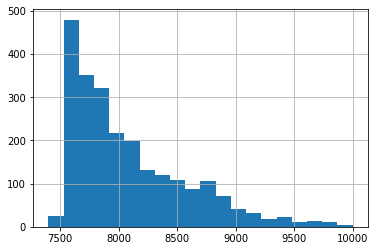

In [4]:
answers_df.reaction_time.hist(bins=20, range=(7400, 10000))

<AxesSubplot:xlabel='block', ylabel='reaction_time'>

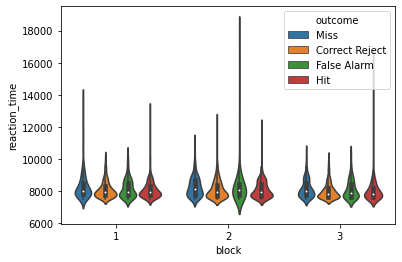

In [5]:
seaborn.violinplot(
    x='block', y='reaction_time', hue='outcome', data=answers_df,
)

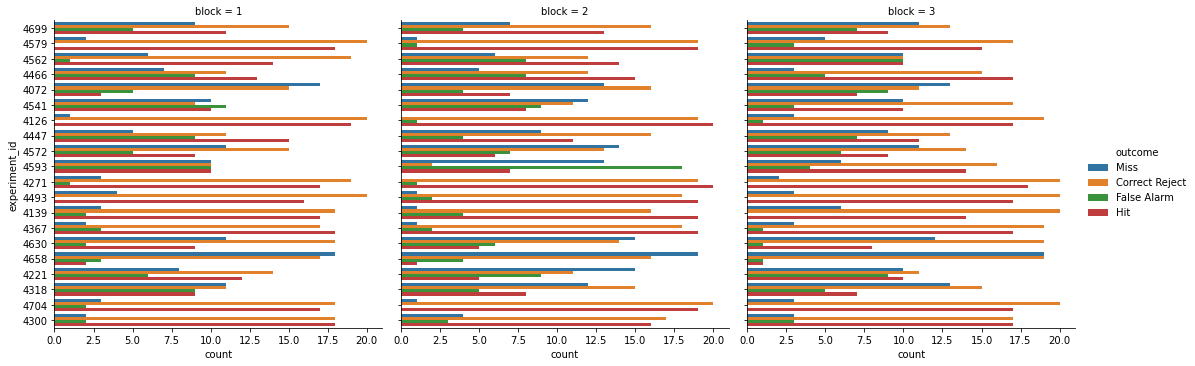

In [6]:
seaborn.catplot(y='experiment_id', hue='outcome', col='block', kind='count', data=answers_df)

In [7]:
columns = set(answers_df.outcome)
rate_dict = dict()
for experiment_id in set(answers_df.experiment_id):
    edf = answers_df[answers_df.experiment_id == experiment_id]
    d = {column: len(edf[edf.outcome==column])/60 for column in columns}
    d['rate'] = (d['Hit'] + d['Correct Reject'])/2
    rate_dict[experiment_id] = d
rate_df = pandas.DataFrame.from_dict(rate_dict, orient='index')
rate_df.to_csv(dir_path/'correct_rate.csv')
rate_df.head()

,Hit,False Alarm,Correct Reject,Miss,rate
4139,0.833333,0.100000,0.900000,0.166667,0.866667
4072,0.283333,0.300000,0.700000,0.716667,0.491667
4466,0.750000,0.366667,0.633333,0.250000,0.691667
4447,0.616667,0.333333,0.666667,0.383333,0.641667
4221,0.450000,0.400000,0.600000,0.550000,0.525000


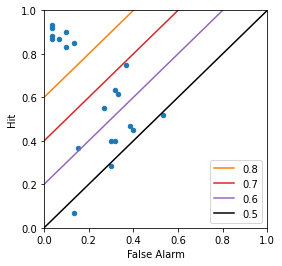

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
rate_df.plot.scatter(x='False Alarm', y='Hit', xlim=(0, 1), ylim=(0, 1), ax=ax)

#ax.plot([0, 0.3], [0.7, 1], color='C4', label=0.85)
ax.plot([0, 0.4], [0.6, 1], color='C1', label=0.8)
#ax.plot([0, 0.5], [0.5, 1], color='C2', label=0.75)
ax.plot([0, 0.6], [0.4, 1], color='C3', label=0.7)
ax.plot([0, 0.8], [0.2, 1], color='C4', label=0.6)
ax.plot([1., 0.], [1., 0.], color='k', label=0.5)
plt.legend()

In [9]:
criteria = 0.8
print(*rate_df[rate_df.rate < criteria].index, sep='\n')

4072
4466
4447
4221
4562
4572
4630
4318
4699
4541
4593
4658
